# 🍷 Şarap Kalitesi Analizi — Keşifsel Veri Analizi (EDA)

**Veri Seti:** WineQT.csv — Kırmızı Şarap Kalitesi  

---

## 🎯 Proje Amacı

Bu notebook, kırmızı şarap örneklerine ait fizikokimyasal ölçümleri ve kalite puanlarını analiz etmektedir.  
Temel sorularımız:

1. **Alkol miktarı** ile kalite arasında nasıl bir ilişki var?
2. **Asitlik, pH ve yoğunluk** kaliteyi belirliyor mu?
3. **Hangi özellikler** en güçlü korelasyona sahip?
4. **Kalite sınıfları** arasında kimyasal dağılımlar nasıl ayrışıyor?

## 📁 Veri Seti Sözlüğü

| Kolon | Açıklama | Birim |
|---|---|---|
| `fixed acidity` | Uçucu olmayan asit miktarı | g/dm³ |
| `volatile acidity` | Asetik asit (yüksekse hoş olmayan tat) | g/dm³ |
| `citric acid` | Sitrik asit (tazelik katkısı) | g/dm³ |
| `residual sugar` | Fermentasyon sonrası kalan şeker | g/dm³ |
| `chlorides` | Tuz miktarı | g/dm³ |
| `free sulfur dioxide` | Serbest SO₂ (antimikrobiyal) | mg/dm³ |
| `total sulfur dioxide` | Toplam SO₂ | mg/dm³ |
| `density` | Şarabın yoğunluğu | g/cm³ |
| `pH` | Asitlik düzeyi (0-14 skalası) | — |
| `sulphates` | Sülfat miktarı | g/dm³ |
| `alcohol` | Alkol oranı | % hacim |
| `quality` | Duyusal kalite puanı (0–10) | — |
| `Id` | Örnek kimlik numarası | — |

---

## 1. Kütüphaneler ve Genel Ayarlar

- **pandas / numpy**: Veri manipülasyonu ve istatistik  
- **matplotlib / seaborn**: Görselleştirme  

> ⚙️ `sns.set_theme()` ile tüm grafiklerde tutarlı bir görünüm sağlıyoruz.  
> `rcParams` ile DPI ve etiket aralıkları merkezi olarak ayarlanır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlepad': 14,
    'axes.labelpad': 8,
})

PALETTE  = sns.color_palette('Reds_d', 6)   # Kalite sınıfları için ana palet
ACCENT   = '#2B4590'                          # Vurgu rengi (mavi)
QUAL_PAL = sns.color_palette('YlOrRd', 6)    # quality bazlı grafikler için

print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme ve İlk İnceleme

Veriyi okuduktan sonra **shape**, **dtypes**, **eksik değer** ve **temel istatistik** kontrolü yapıyoruz.  
Bu adım her EDA'nın zorunlu ilk durağıdır — veri hakkında sezgi geliştirmeyi ve olası sorunları erken tespit etmeyi sağlar.

In [2]:
df = pd.read_csv('WineQT.csv')

print(f'Boyut       : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Eksik değer : {df.isnull().sum().sum()} adet\n')
print('Sütun tipleri:')
print(df.dtypes.to_string())
df.head(10)

Boyut       : 1,143 satır × 13 sütun
Eksik değer : 0 adet

Sütun tipleri:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [4]:
# Eksik değer analizi — sütun bazında görselleştirme
missing = df.isnull().sum()

if missing.sum() == 0:
    print('✅ Veri setinde hiç eksik (NaN) değer yok.')
else:
    missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
    print(missing_pct[missing_pct > 0].to_string())

✅ Veri setinde hiç eksik (NaN) değer yok.


---
## 3. Hedef Değişken: Kalite Dağılımı

`quality` sütunu modelimizin **hedef değişkenidir** (regresyon veya sınıflandırma).  
Kalite puanlarının dağılımını incelemek; sınıf dengesizliğini, merkezi eğilimi ve veriyi anlamak açısından kritiktir.

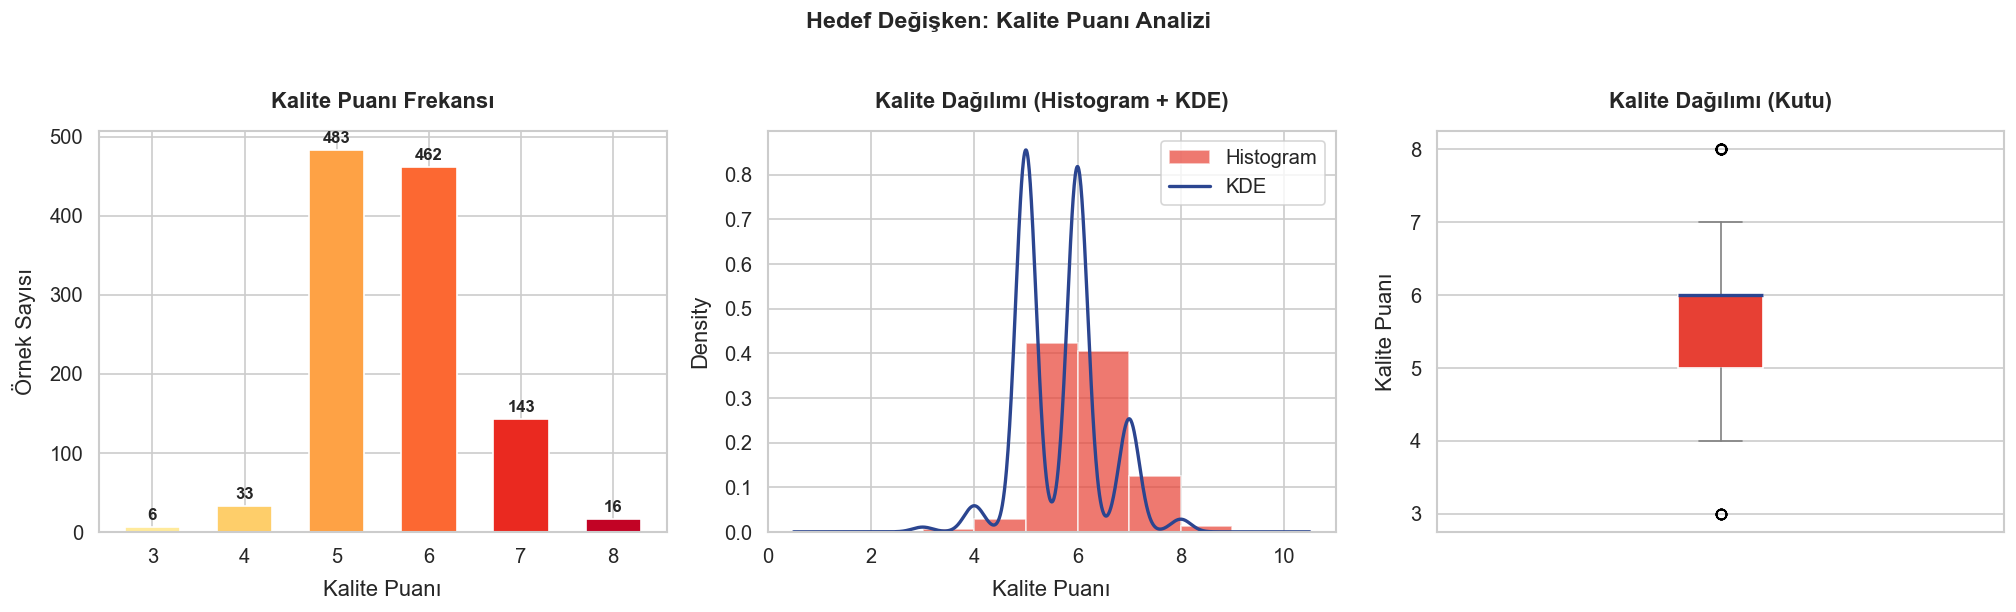

Kalite puanları: [3, 4, 5, 6, 7, 8]
Ortalama : 5.66
Medyan   : 6
Mod      : 5


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

quality_counts = df['quality'].value_counts().sort_index()

# Bar grafik
bars = axes[0].bar(
    quality_counts.index.astype(str),
    quality_counts.values,
    color=QUAL_PAL, edgecolor='white', width=0.6
)
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Kalite Puanı Frekansı', fontweight='bold')
axes[0].set_xlabel('Kalite Puanı')
axes[0].set_ylabel('Örnek Sayısı')

# KDE — sürekli dağılım
axes[1].hist(df['quality'], bins=range(2, 10), color=PALETTE[2],
             edgecolor='white', density=True, alpha=0.7, label='Histogram')
df['quality'].plot(kind='kde', ax=axes[1], color=ACCENT, lw=2, label='KDE')
axes[1].set_title('Kalite Dağılımı (Histogram + KDE)', fontweight='bold')
axes[1].set_xlabel('Kalite Puanı')
axes[1].legend()

# Kutu grafiği — merkez ve aykırı değerler
axes[2].boxplot(df['quality'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color='white'),
                medianprops=dict(color=ACCENT, linewidth=2),
                whiskerprops=dict(color='gray'),
                capprops=dict(color='gray'))
axes[2].set_title('Kalite Dağılımı (Kutu)', fontweight='bold')
axes[2].set_ylabel('Kalite Puanı')
axes[2].set_xticks([])

plt.suptitle('Hedef Değişken: Kalite Puanı Analizi', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Kalite puanları: {sorted(df["quality"].unique())}')
print(f'Ortalama : {df["quality"].mean():.2f}')
print(f'Medyan   : {df["quality"].median():.0f}')
print(f'Mod      : {df["quality"].mode()[0]}')

---
## 4. Tüm Özelliklerin Dağılımı

Her sayısal özelliğin dağılım şeklini kalite sınıflarına göre **KDE (Kernel Density Estimation)** ile görselleştiriyoruz.  
KDE, histogramın süreklilik kazandırılmış versiyonudur; farklı kalite gruplarının hangi değer aralıklarında yoğunlaştığını ortaya koyar.

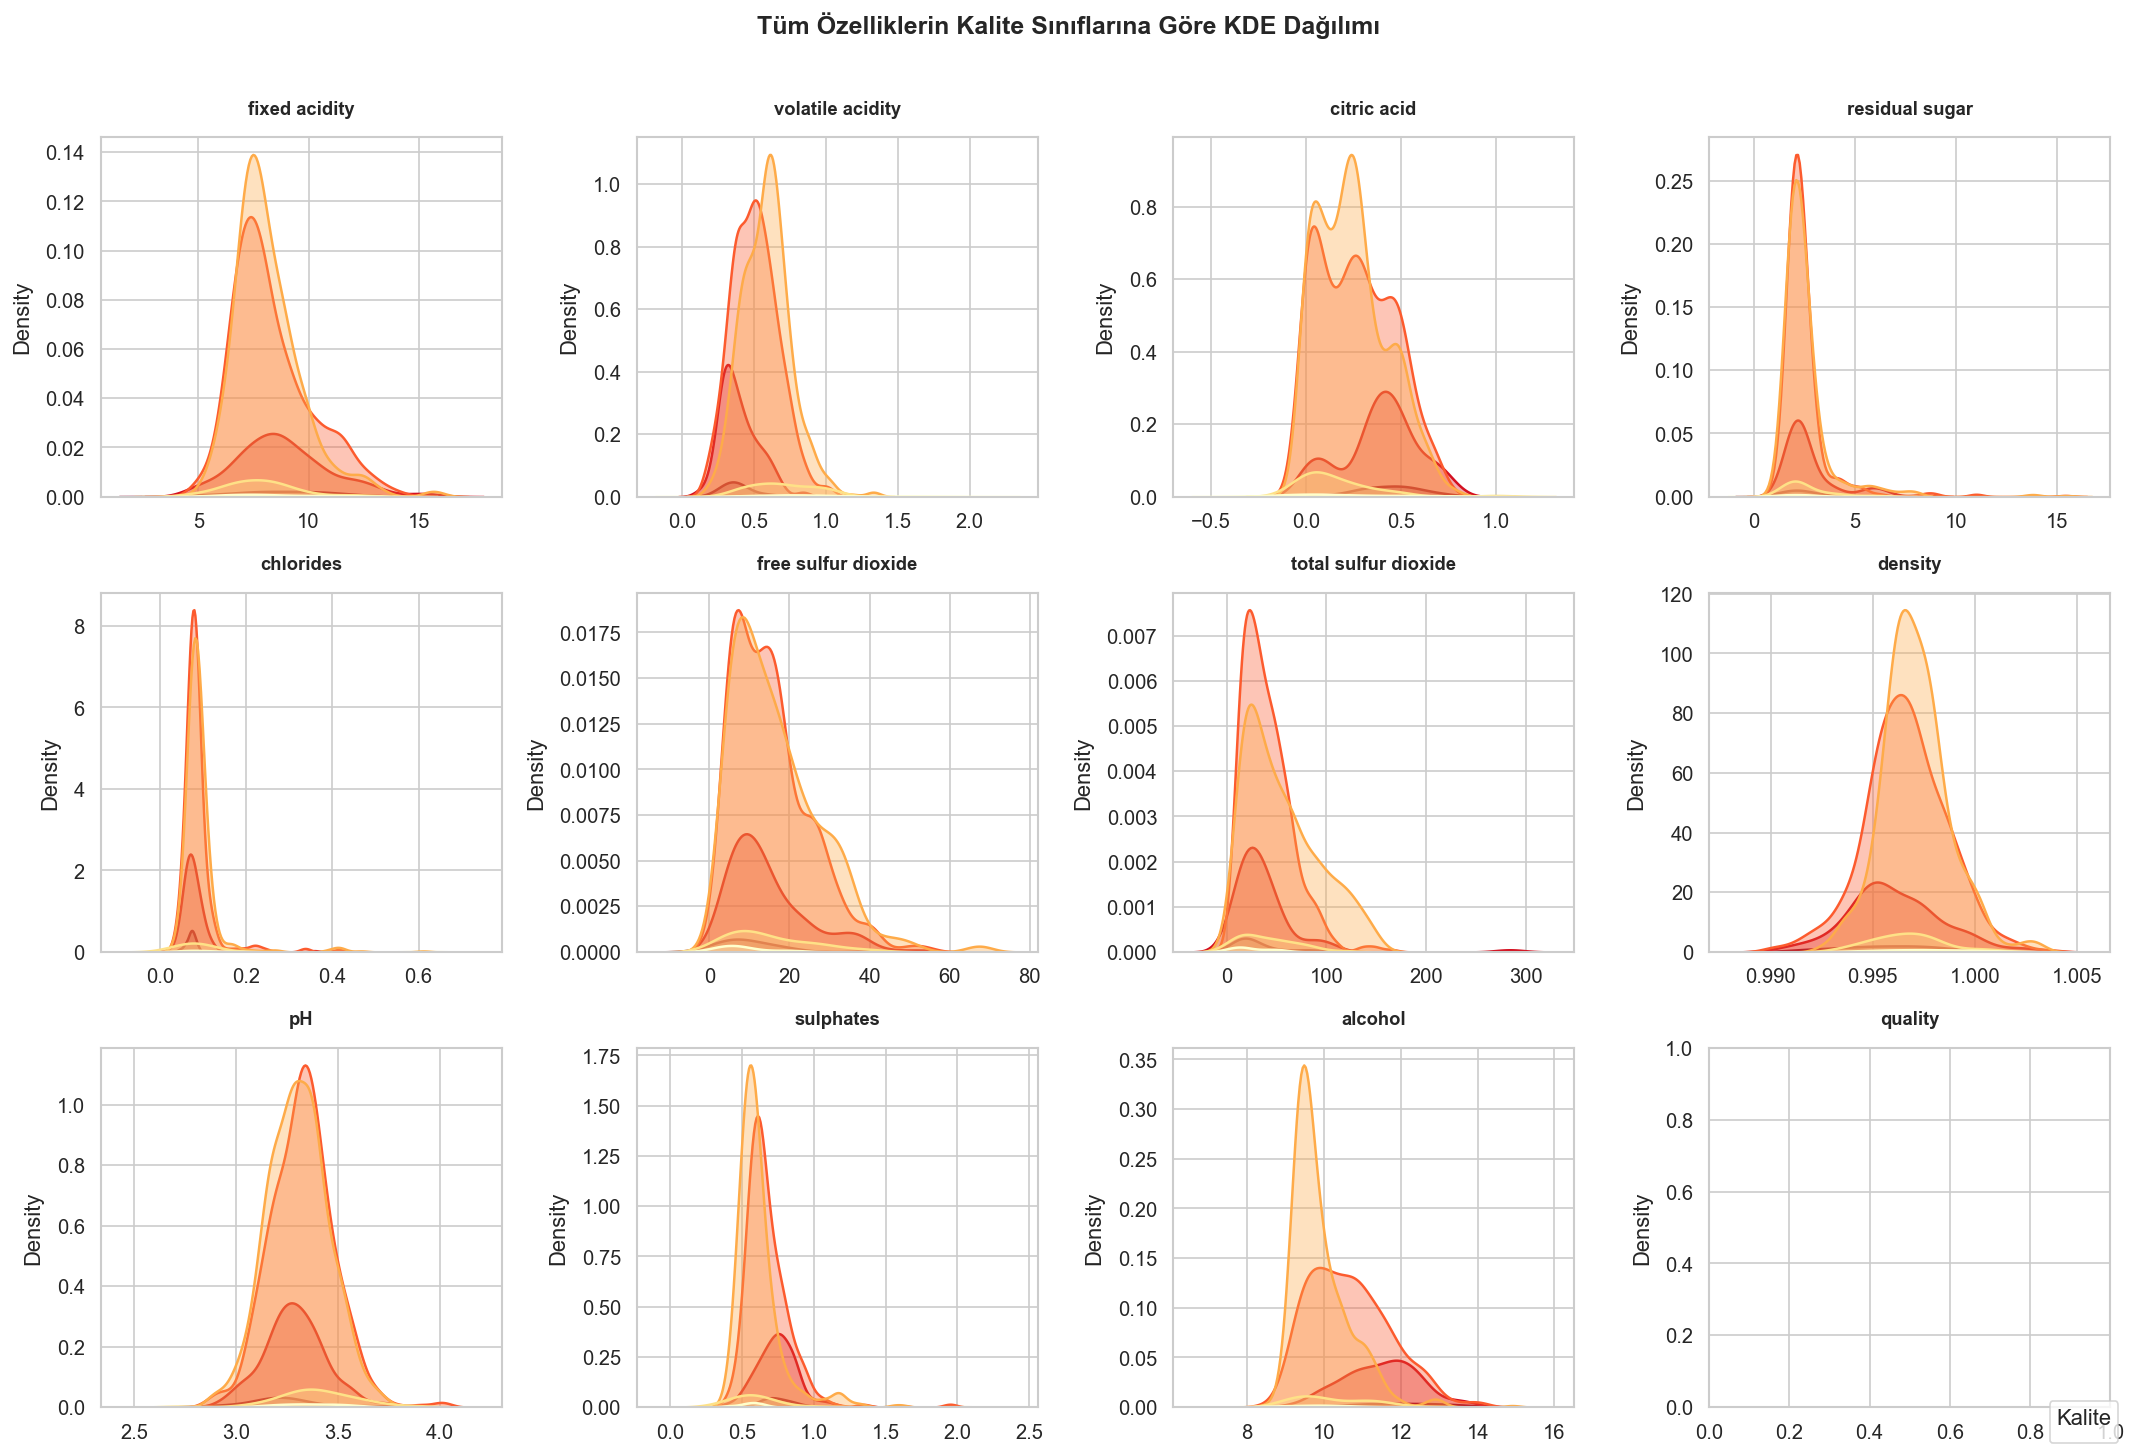

In [6]:
# Id sütununu dağılım analizinden çıkarıyoruz — sadece bir kimlik numarası
feature_cols = [c for c in df.columns if c != 'Id']

n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
ax = ax.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='quality',
        palette='YlOrRd',
        fill=True,
        alpha=0.35,
        linewidth=1.5,
        ax=ax[i]
    )
    ax[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    ax[i].set_xlabel(None)
    ax[i].get_legend().remove() if ax[i].get_legend() else None

# Kullanılmayan eksenleri kapat
for j in range(i + 1, len(ax)):
    ax[j].axis('off')

# Ortak legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kalite', loc='lower right',
           bbox_to_anchor=(0.99, 0.01), ncol=3, fontsize=10)

plt.suptitle('Tüm Özelliklerin Kalite Sınıflarına Göre KDE Dağılımı',
             y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Alkol × Kalite İlişkisi

Alkol oranı, şarap kalitesiyle en güçlü ilişkiye sahip özelliklerden biri olarak öne çıkmaktadır.  
Box plot ile her kalite sınıfındaki alkol dağılımını, scatter plot ile ise genel örüntüyü inceliyoruz.

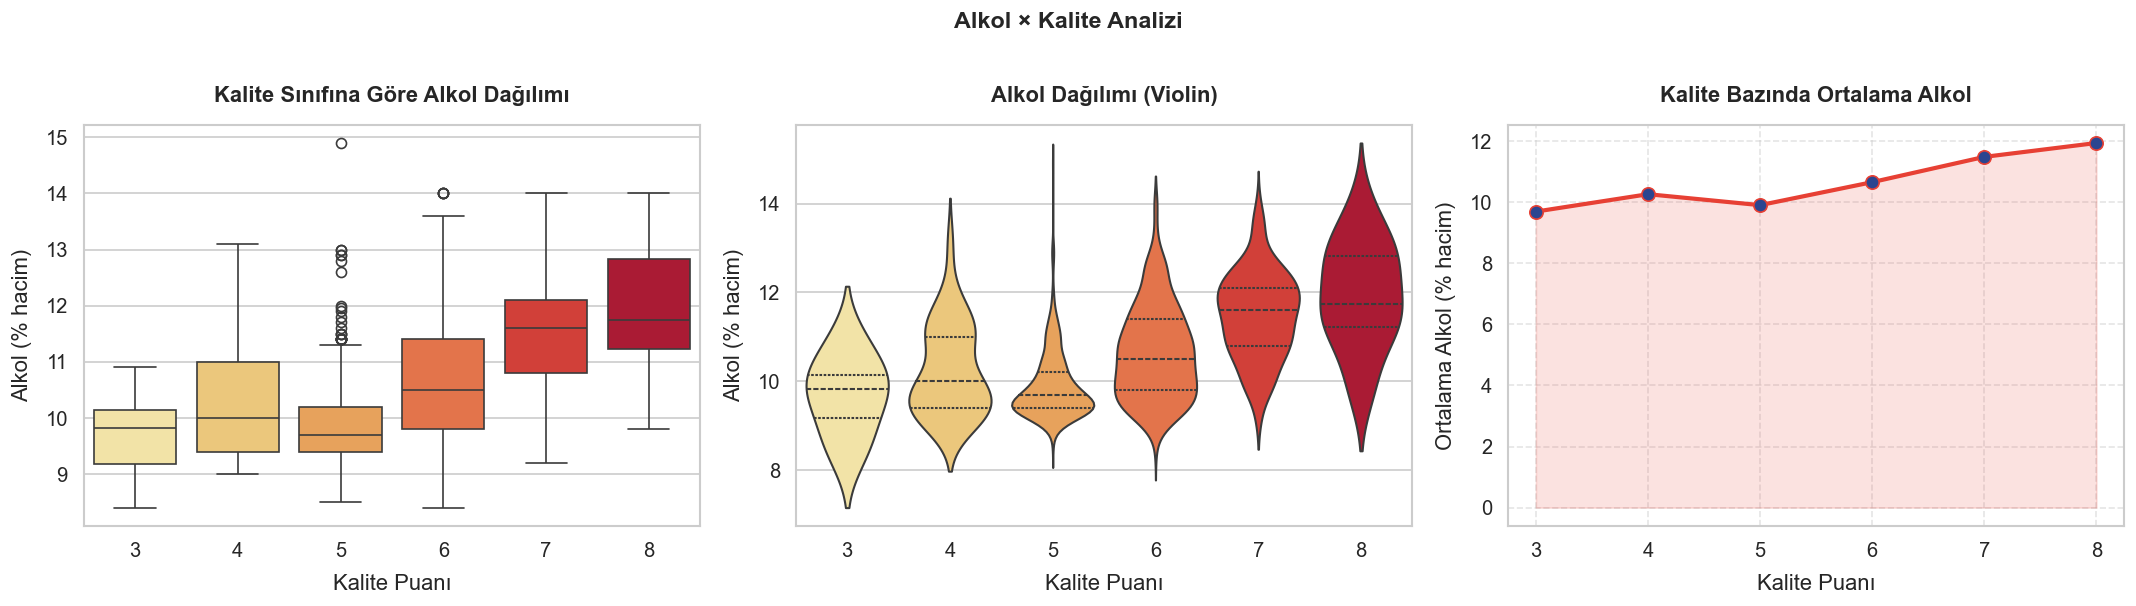

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kutu grafiği — alkol × kalite
sns.boxplot(
    data=df, x='quality', y='alcohol',
    palette='YlOrRd', ax=axes[0]
)
axes[0].set_title('Kalite Sınıfına Göre Alkol Dağılımı', fontweight='bold')
axes[0].set_xlabel('Kalite Puanı')
axes[0].set_ylabel('Alkol (% hacim)')

# Violin — dağılım şekli daha belirgin
sns.violinplot(
    data=df, x='quality', y='alcohol',
    palette='YlOrRd', inner='quartile', ax=axes[1]
)
axes[1].set_title('Alkol Dağılımı (Violin)', fontweight='bold')
axes[1].set_xlabel('Kalite Puanı')
axes[1].set_ylabel('Alkol (% hacim)')

# Ortalama alkol per kalite çizgi grafiği
mean_alc = df.groupby('quality')['alcohol'].mean()
axes[2].plot(mean_alc.index, mean_alc.values, 'o-', color=PALETTE[2],
             lw=2.5, ms=8, markerfacecolor=ACCENT)
axes[2].fill_between(mean_alc.index, mean_alc.values, alpha=0.15, color=PALETTE[2])
axes[2].set_title('Kalite Bazında Ortalama Alkol', fontweight='bold')
axes[2].set_xlabel('Kalite Puanı')
axes[2].set_ylabel('Ortalama Alkol (% hacim)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Alkol × Kalite Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Asitlik × Yoğunluk × Kalite İlişkisi

Scatter plot ile iki sürekli değişkeni aynı anda görselleştirebiliyoruz.  
`hue='quality'` parametresi sayesinde kalite sınıfları renk kodlamasıyla ayrıştırılır — bu yöntem boyut sayısını görsel olarak artırır.

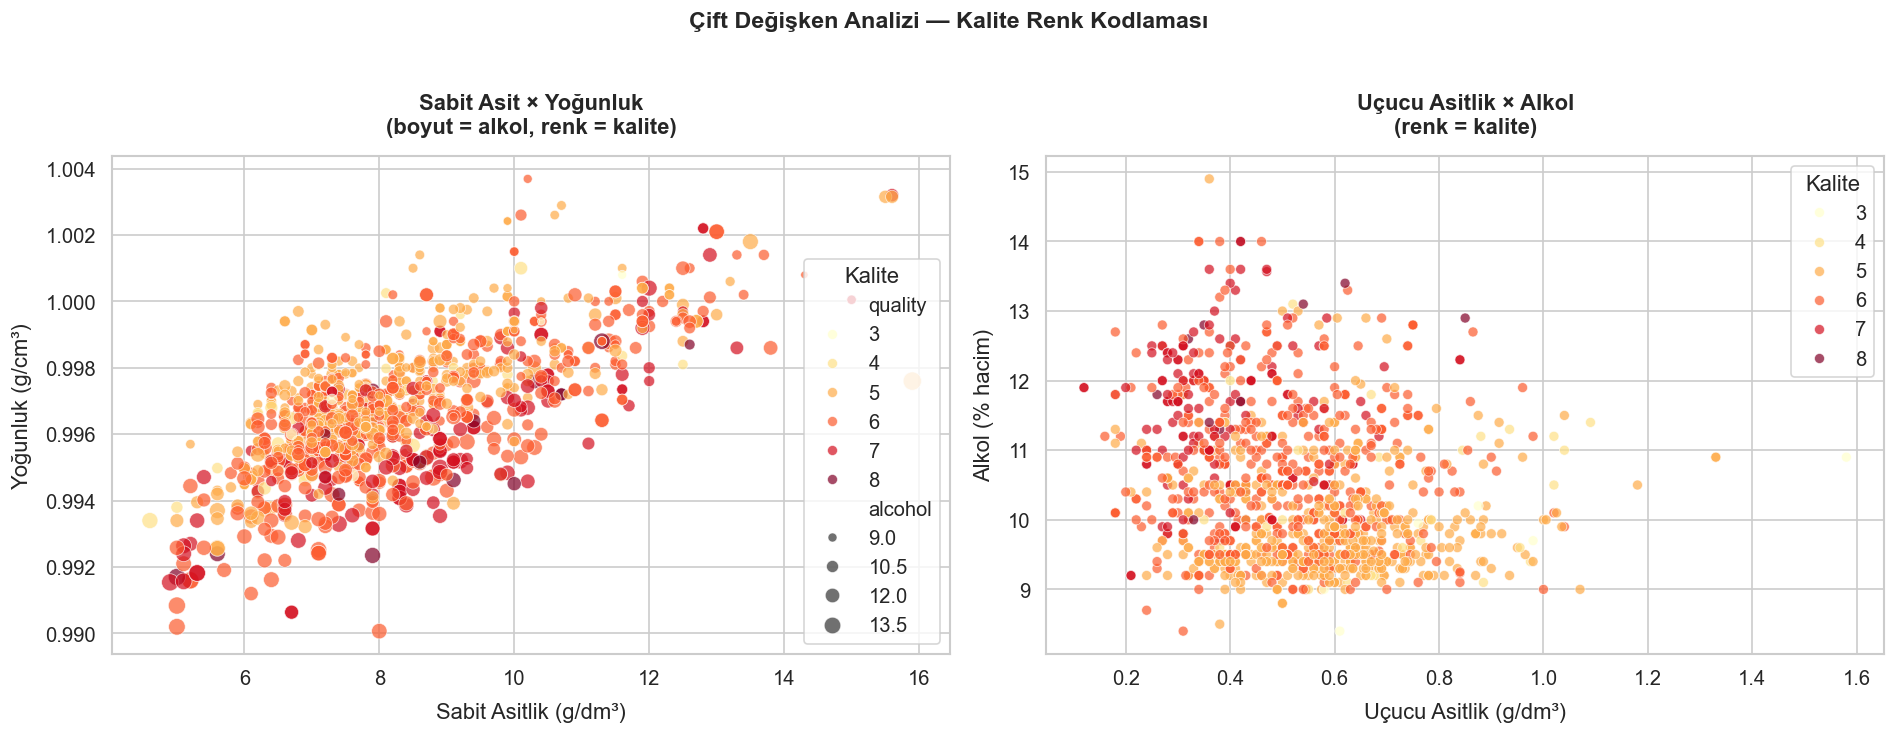

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sabit asit × yoğunluk (hue = kalite)
scatter1 = sns.scatterplot(
    data=df, x='fixed acidity', y='density',
    hue='quality', palette='YlOrRd',
    size='alcohol', sizes=(20, 120),
    alpha=0.7, ax=axes[0]
)
axes[0].set_title('Sabit Asit × Yoğunluk\n(boyut = alkol, renk = kalite)', fontweight='bold')
axes[0].set_xlabel('Sabit Asitlik (g/dm³)')
axes[0].set_ylabel('Yoğunluk (g/cm³)')
axes[0].get_legend().set_title('Kalite')

# Uçucu asit × alkol (hue = kalite)
sns.scatterplot(
    data=df, x='volatile acidity', y='alcohol',
    hue='quality', palette='YlOrRd',
    alpha=0.7, ax=axes[1]
)
axes[1].set_title('Uçucu Asitlik × Alkol\n(renk = kalite)', fontweight='bold')
axes[1].set_xlabel('Uçucu Asitlik (g/dm³)')
axes[1].set_ylabel('Alkol (% hacim)')
axes[1].get_legend().set_title('Kalite')

plt.suptitle('Çift Değişken Analizi — Kalite Renk Kodlaması', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Korelasyon Matrisi

Özellikler arasındaki **Pearson korelasyonunu** ısı haritasıyla görselleştiriyoruz.  
- **+1'e yakın**: Güçlü pozitif ilişki  
- **–1'e yakın**: Güçlü negatif ilişki  
- **0'a yakın**: Zayıf / anlamsız ilişki  

Üst üçgeni maskeliyoruz çünkü matris simetriktir — alt üçgen yeterlidir ve okunabilirliği artırır.

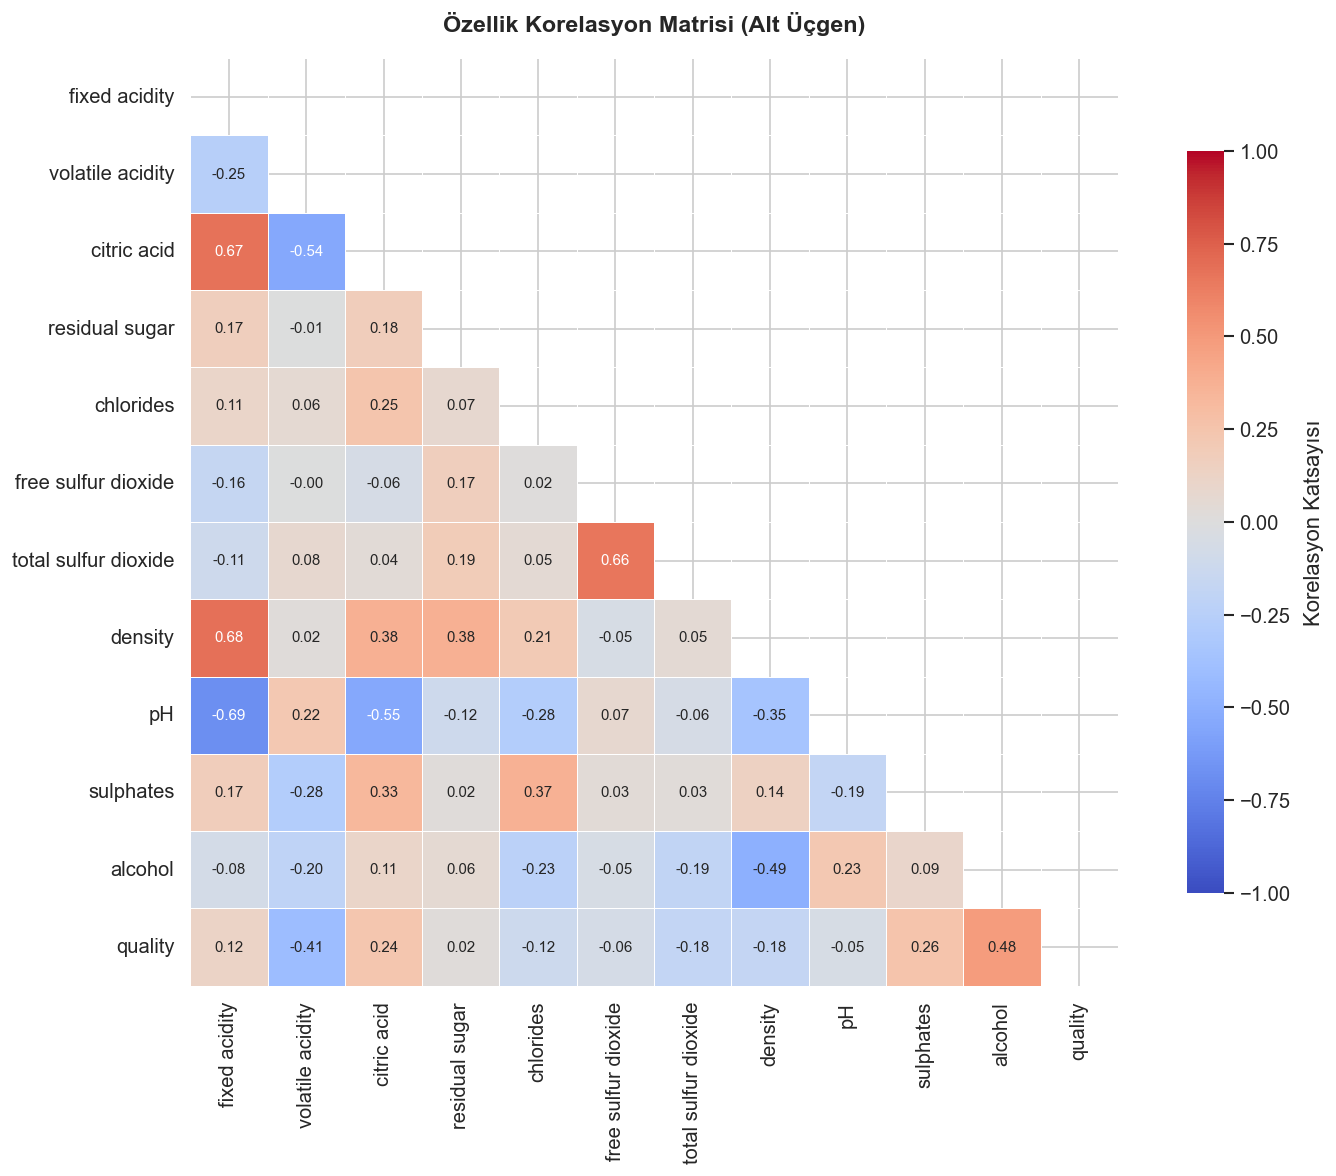


📈 Hedef değişken (quality) ile korelasyon (mutlak değer, büyükten küçüğe):
alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002


In [9]:
corr = df.drop(columns=['Id']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Üst üçgen maskeleme

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayısı'},
    ax=ax
)
ax.set_title('Özellik Korelasyon Matrisi (Alt Üçgen)', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

# quality ile en güçlü korelasyonlar
target_corr = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
print('\n📈 Hedef değişken (quality) ile korelasyon (mutlak değer, büyükten küçüğe):')
print(target_corr.to_string())

---
## 8. Pairplot — Önemli Özellikler Arası İlişkiler

Korelasyon matrisinden en güçlü ilişkiye sahip özelliklerle bir **pairplot** oluşturuyoruz.  
Pairplot her ikili kombinasyonu scatter, köşegen eksenleri ise KDE/histogram ile gösterir.  
Tüm 13 sütunu pairplot'a vermek aşırı kalabalık yaratır; seçici bir alt küme daha bilgilendirici olur.

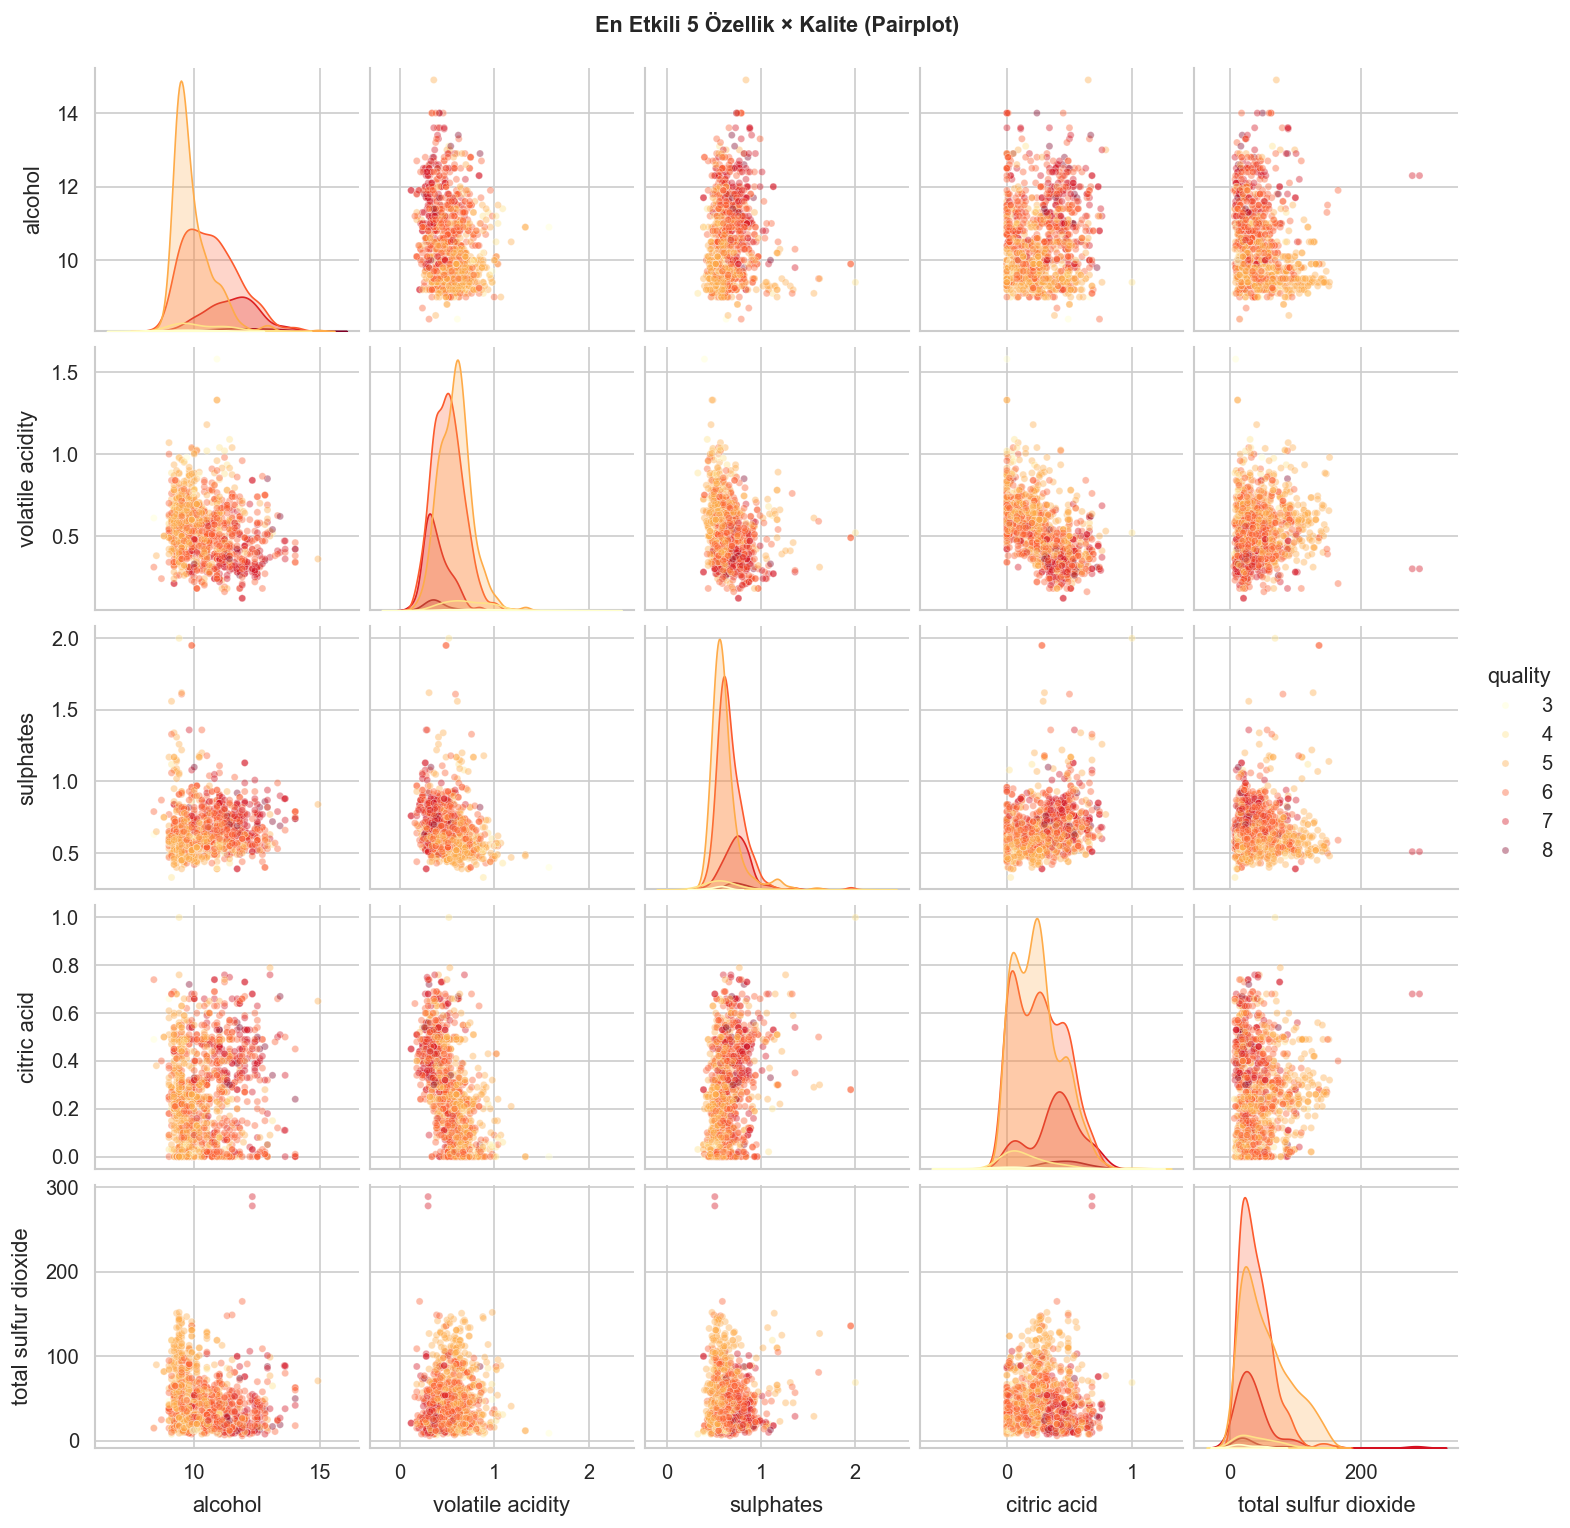

In [10]:
# Kaliteyle en yüksek mutlak korelasyona sahip 5 özellik + quality
top_features = target_corr.head(5).index.tolist() + ['quality']

g = sns.pairplot(
    df[top_features],
    hue='quality',
    palette='YlOrRd',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 18},
    diag_kws={'fill': True}
)
g.fig.suptitle('En Etkili 5 Özellik × Kalite (Pairplot)',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 9. Id Bazlı Özellik Dağılımı

Tüm özelliklerin Id ekseninde nasıl dağıldığını birlikte görselleştiriyoruz.  
Bu grafik; aykırı değerleri, örnekler arası varyasyonu ve olası veri giriş hatalarını keşfetmeye yarar.  

> ⚠️ Ölçekler birbirinden çok farklı olduğu için sütunları birbirine göre yorumlamak yanıltıcı olabilir. Grafik veri sağlamlığı kontrolü içindir.

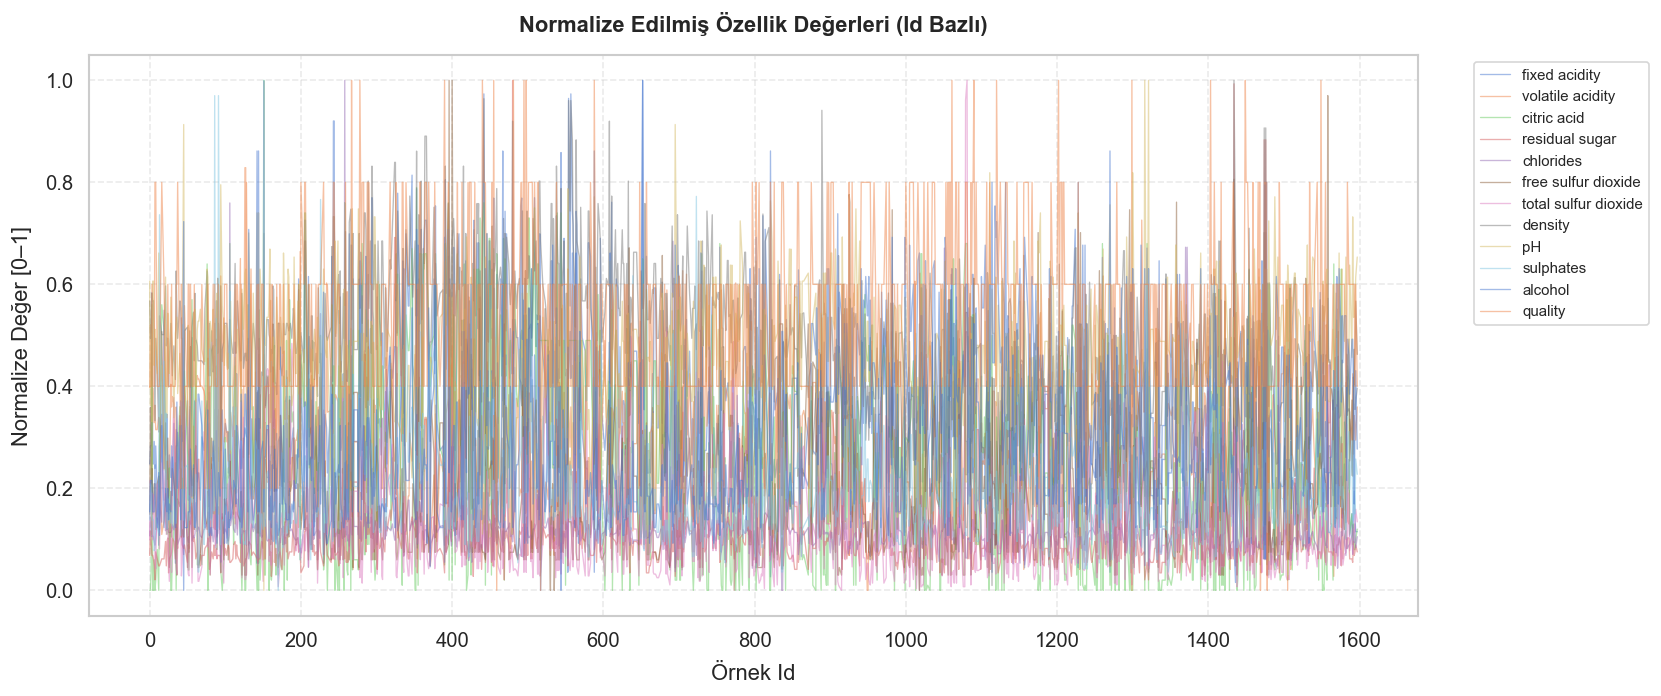

In [11]:
# Tüm özellikleri normalize ederek tek grafik — karşılaştırılabilir ölçek
from sklearn.preprocessing import MinMaxScaler

try:
    scaler = MinMaxScaler()
    plot_cols = [c for c in df.columns if c != 'Id']
    df_norm = pd.DataFrame(
        scaler.fit_transform(df[plot_cols]),
        columns=plot_cols
    )
    df_norm['Id'] = df['Id'].values

    fig, ax = plt.subplots(figsize=(14, 6))
    for col in plot_cols:
        ax.plot(df_norm['Id'], df_norm[col], alpha=0.5, lw=0.8, label=col)

    ax.set_title('Normalize Edilmiş Özellik Değerleri (Id Bazlı)', fontweight='bold')
    ax.set_xlabel('Örnek Id')
    ax.set_ylabel('Normalize Değer [0–1]')
    ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=9, ncol=1)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

except ImportError:
    # sklearn yoksa ham değerlerle çiz
    fig, ax = plt.subplots(figsize=(14, 6))
    for col in [c for c in df.columns if c != 'Id']:
        ax.plot(df['Id'], df[col], alpha=0.5, lw=0.8, label=col)
    ax.set_title('Özellik Değerleri (Id Bazlı)', fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 10. Gruplama Analizi — Kalite Bazında Kimyasal Profil

`groupby` ile her kalite sınıfının ortalama kimyasal profilini çıkarıyoruz.  
Bu tablo, bir modelin gözlemleyeceği temel kalıpları insan gözüyle özetler.

In [14]:
quality_profile = (
    df.drop(columns=['Id'])
    .groupby('quality')
    .agg(['mean', 'median', 'std'])
    .round(3)
)

# Ortalama profil
mean_profile = df.drop(columns=['Id']).groupby('quality').mean().round(3)
print('📊 Kalite Sınıfı Bazında Ortalama Kimyasal Profil:')
mean_profile.style.background_gradient(cmap='Reds', axis=0)


from IPython.display import display

# 1. Tüm istatistikleri tek seferde hesapla
quality_profile = (
    df.drop(columns=['Id'])
    .groupby('quality')
    .agg(['mean', 'median', 'std'])
    .round(3)
)

# 2. Daha önce hesaplanmış veriden sadece 'mean' kolonlarını çek (Level 1 index)
mean_profile = quality_profile.xs('mean', level=1, axis=1)

print('📊 Kalite Sınıfı Bazında Ortalama Kimyasal Profil:')
# 3. Notebook'ta düzgün render edilmesi için display() kullan
display(mean_profile.style.background_gradient(cmap='Reds', axis=0))

📊 Kalite Sınıfı Bazında Ortalama Kimyasal Profil:
📊 Kalite Sınıfı Bazında Ortalama Kimyasal Profil:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450000,0.898000,0.212000,2.667000,0.105000,8.167000,24.500000,0.998000,3.362000,0.550000,9.692000
4,7.809000,0.700000,0.166000,2.567000,0.095000,14.848000,40.606000,0.997000,3.391000,0.638000,10.261000
5,8.161000,0.585000,0.240000,2.540000,0.092000,16.613000,55.299000,0.997000,3.302000,0.613000,9.902000
6,8.318000,0.505000,0.264000,2.445000,0.085000,15.215000,39.942000,0.997000,3.324000,0.677000,10.655000
7,8.851000,0.394000,0.387000,2.760000,0.075000,14.538000,37.490000,0.996000,3.287000,0.744000,11.483000
8,8.806000,0.410000,0.432000,2.644000,0.070000,11.062000,29.375000,0.996000,3.241000,0.766000,11.938000


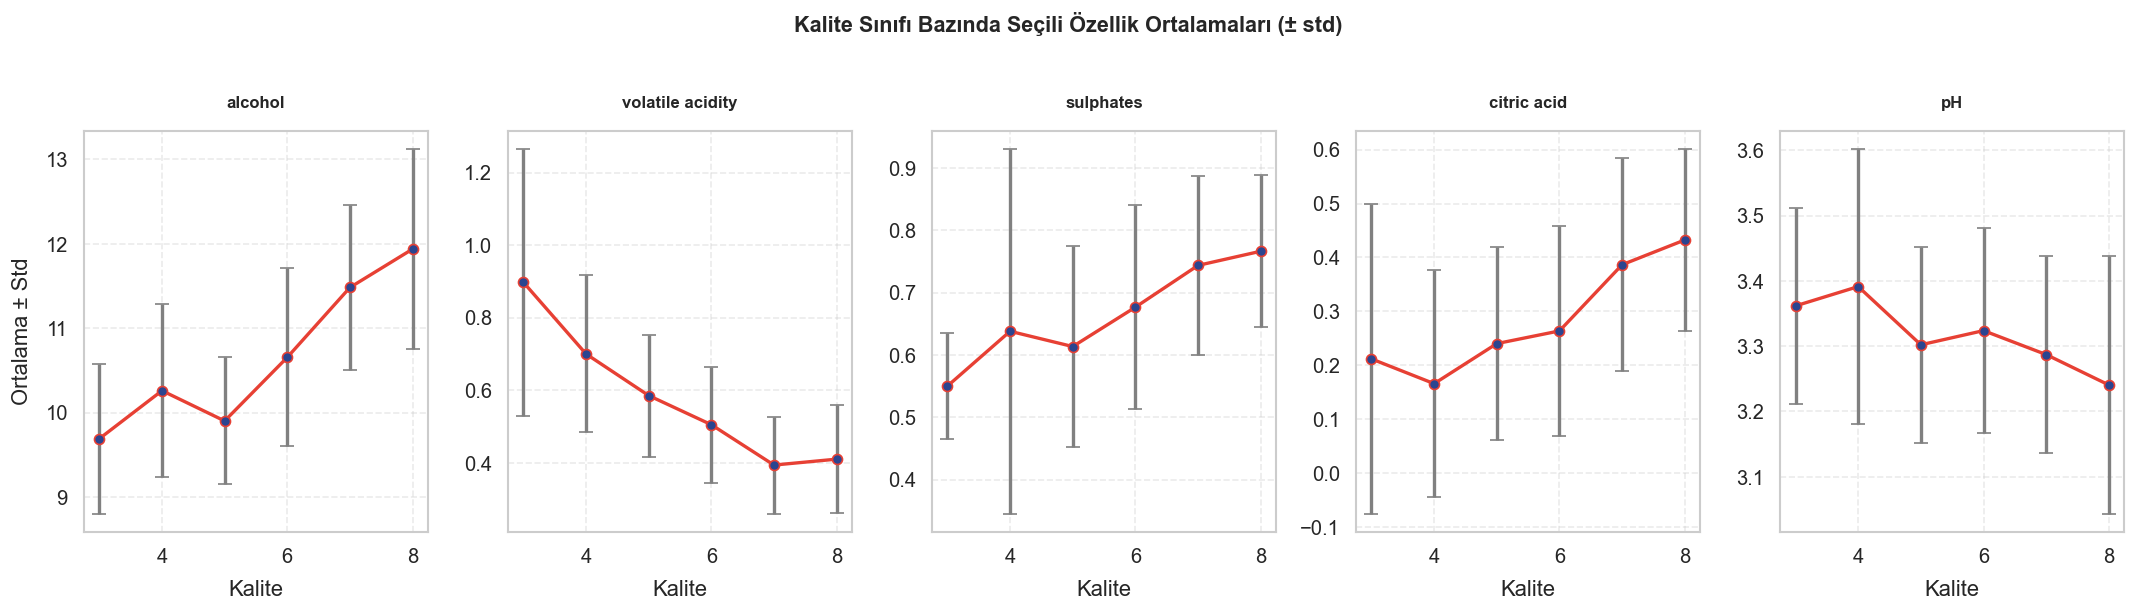

In [15]:
# Seçili özellikler için çizgi grafik — kalite grupları arası fark
SELECTED_FEATURES = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'pH']

fig, axes = plt.subplots(1, len(SELECTED_FEATURES), figsize=(18, 5), sharey=False)

for i, feat in enumerate(SELECTED_FEATURES):
    qual_mean = df.groupby('quality')[feat].mean()
    qual_std  = df.groupby('quality')[feat].std()
    axes[i].errorbar(
        qual_mean.index, qual_mean.values,
        yerr=qual_std.values, fmt='o-',
        color=PALETTE[2], ecolor='gray',
        capsize=4, lw=2, ms=6, markerfacecolor=ACCENT
    )
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Kalite')
    axes[i].grid(True, linestyle='--', alpha=0.4)
    if i == 0:
        axes[i].set_ylabel('Ortalama ± Std')

plt.suptitle('Kalite Sınıfı Bazında Seçili Özellik Ortalamaları (± std)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Özet ve Sonraki Adımlar

### ✅ Bu notebook'ta yapılanlar

| Adım | İşlem | Amaç |
|---|---|---|
| 2 | Veri yükleme + ilk inceleme | Kalite kontrolü, eksik değer tespiti |
| 3 | Hedef değişken analizi | Sınıf dağılımı, dengesizlik tespiti |
| 4 | KDE dağılım ızgarası | Tüm özelliklerin kaliteye göre profili |
| 5 | Alkol × kalite analizi | En önemli özelliğin derinlemesine incelenmesi |
| 6 | Scatter plotlar | Çift değişkenli ilişki + kalite renk kodlaması |
| 7 | Korelasyon matrisi | Özellikler arası doğrusal ilişki tespiti |
| 8 | Pairplot | En bilgilendirici özellik kombinasyonları |
| 9 | Id bazlı görselleştirme | Aykırı değer / veri sağlamlığı kontrolü |
| 10 | Gruplama analizi | Kalite sınıflarının kimyasal profili |

### 🔑 Temel Bulgular

- **Alkol** kaliteyle en yüksek pozitif korelasyona sahip özelliktir.
- **Uçucu asitlik** kaliteyle negatif korelasyonludur — yüksek uçucu asit, düşük kaliteyi işaret eder.
- **Sabit asitlik ve yoğunluk** güçlü pozitif korelasyon gösterir (fiziksel beklentiyle uyumlu).
- Kalite puanları **5–6** aralığında yoğunlaşmaktadır (sınıf dengesizliği var).